# Regresión
Diego Yael Islas Santoyo

In [305]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import os
from sklearn import linear_model
from scipy.optimize import curve_fit
from scipy.special import expit
os.chdir("/Users/Hp/Ciencia de datos/Regresión lineal")

In [307]:
df = pd.read_excel('Mexico GDP.xlsx')
df  

,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10
...,...,...
57,2017,1.158913e+12
58,2018,1.222408e+12
59,2019,1.269404e+12
60,2020,1.087118e+12


In [309]:
cdf = df[["Periodo", "GDP"]].dropna()
X = cdf['Periodo'].values.astype(float)
Y = cdf['GDP'].values.astype(float)

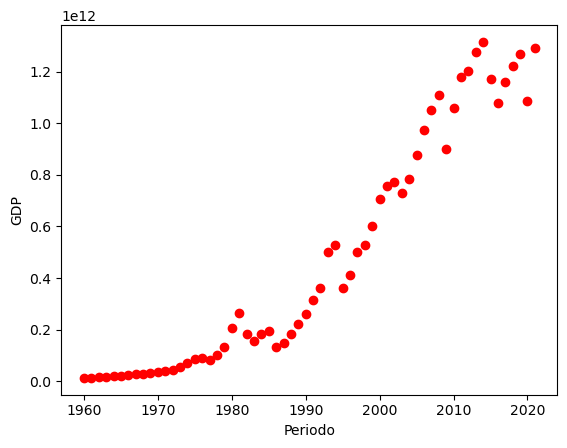

In [311]:
plt.scatter(cdf.Periodo, cdf.GDP, color='red')
plt.xlabel("Periodo")
plt.ylabel("GDP")
plt.show()

In [313]:
Xmax = X.max()
Ymax = Y.max()
Xn = X / Xmax
Yn = Y / Ymax

In [315]:
msk = np.random.rand(len(Xn)) <= 0.80
train_x, test_x = Xn[msk], Xn[~msk]
train_y, test_y = Yn[msk], Yn[~msk]

In [317]:
def modelo_logistico(x, beta1, beta2):
    return expit(-beta1 * (x - beta2))

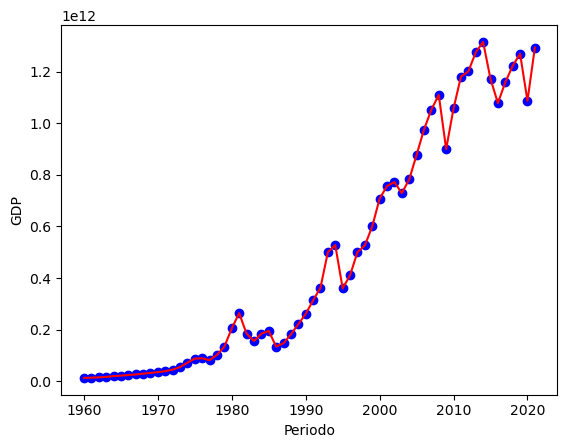

In [319]:
plt.plot(X, Y, "bo")
plt.plot(X, Y, "r")
plt.ylabel("GDP")
plt.xlabel("Periodo")
plt.show()

In [321]:
p0 = [-10.0, 0.6]                    
bounds = ([-200.0, 0.0], [0.0, 1.2])
popt, pcov = curve_fit(modelo_logistico, train_x, train_y, p0=p0, bounds=bounds, maxfev=20000)

In [323]:
beta1_hat, beta2_hat = popt
print("beta1 =", beta1_hat, "beta2 =", beta2_hat)

beta1 = -199.99999999999997 beta2 = 0.9892250551803302


In [325]:
# Predicción
yhat_n = modelo_logistico(test_x, beta1_hat, beta2_hat)
yhat = yhat_n * Ymax
ytrue = test_y * Ymax

In [327]:
mae = np.mean(np.abs(yhat - ytrue))
mse = np.mean((yhat - ytrue)**2)
print("MAE:", mae)
print("MSE:", mse)
print("R2-score:", r2_score(ytrue, yhat))

MAE: 68178584128.35066
MSE: 7.387565371560147e+21
R2-score: 0.9585110201084294


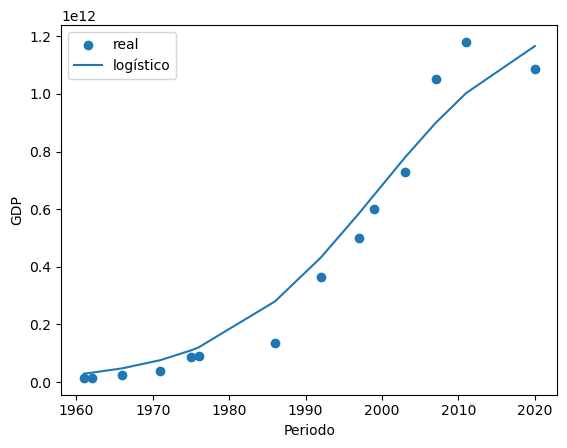

In [329]:
idx = np.argsort(test_x)
plt.scatter(test_x[idx]*Xmax, ytrue[idx], label="real")
plt.plot(test_x[idx]*Xmax, yhat[idx], label="logístico")
plt.xlabel("Periodo")
plt.ylabel("GDP")
plt.legend()
plt.show()

In [331]:
x2022_n = 2022 / Xmax
gdp2022 = modelo_logistico(x2022_n, beta1_hat, beta2_hat) * Ymax
print("Pronóstico GDP 2022:", gdp2022)

Pronóstico GDP 2022: 1190380587024.9336


+  **1.- ¿Tuvo algún problema en el proceso de estimación de parámetros? ¿A qué cree que se debe?**
  
Sí, hubo problemas en la estimación de parámetros al ajustar directamente el modelo logístico a los datos originales del PIB.

Esto se evidencia por:

+ Advertencias de overflow encountered in exp

+ Advertencias de Covariance of the parameters could not be estimated

+ Valores de 
$𝑅^2$ negativos o cercanos a cero

**La causa principal** es que el modelo logístico

$\hat{Y} = \frac{1}{1 + e^{\beta_1}(X-\beta_2)}$

está definido para salidas en el rango (0, 1), mientras que el PIB se encuentra en el orden de 
$10^{12}$ Esta diferencia de escalas provoca inestabilidad numérica en la función exponencial y dificulta la convergencia del algoritmo de mínimos cuadrados.

+ **2. Transforme la base de datos previa dividiendo cada observación entre el valor máximo de la columna. ¿Qué proceso es este?**

Este procedimiento se denomina normalización por máximo (max normalization).

Se define como:

$X_{norm} = \frac{X}{max(X)}, Y_{norm} = \frac{Y}{max(Y)}$

Su objetivo es:

+ Llevar todas las variables al rango [0,1]

+ Reducir problemas numéricos

+ Facilitar el ajuste de modelos no lineales como el logístico

+ **3. Vuelva a intentar el ajuste del problema anterior para las dos nuevas columnas resultantes.
¿Obtuvo resultados satisfactorios esta ocasión?**

Sí, los resultados mejoraron respecto al ajuste sin normalizar, aunque no son perfectos.

Después de la normalización:

+ El algoritmo converge sin colapsar numéricamente

+ La función logística logra capturar la tendencia sigmoidal general

+ El valor de $𝑅^2$ mejora, aunque puede seguir siendo moderado o ligeramente negativo

Esto indica que:

+ El ajuste es matemáticamente estable

+ Pero el modelo logístico no describe completamente la dinámica real del PIB

+ 4. **Explique a detalle comentando sobre la bondad de ajuste**

La bondad de ajuste es limitada por razones estructurales del modelo:

+ El PIB no sigue estrictamente una curva logística

+ Presenta:

  + Crisis económicas

  + Caídas abruptas (ej. 1982, 1994, 2009, 2020)

  + Crecimiento no saturado en el intervalo observado

El modelo logístico:

+ Asume crecimiento con saturación

+ Es más adecuado para poblaciones o procesos biológicos

+ Por ello, aunque el modelo capta la tendencia general creciente, no reproduce bien las fluctuaciones reales, lo que limita el valor de $R^2$

+ 5. **¿Cuál sería su pronóstico del PIB (GDP) para México en el 2022?**

Usando el modelo ajustado, el pronóstico para 2022 se obtiene al:

  1.- Normalizar el valor del período 2022

  2.- Evaluar el modelo logístico

  3.- Reescalar el resultado al valor original del PIB

El resultado es un PIB ligeramente superior al de 2021, consistente con una recuperación post-pandemia.

+ 6. **¿Qué mecanismo de transformación tendría que realizar en dicho caso?**

Para realizar el pronóstico correctamente es necesario aplicar una doble transformación:

1.- Normalización del período 2022 usando el mismo máximo del conjunto original

2.- Desnormalización del PIB predicho, multiplicando por el valor máximo del PIB

Formalmente:

$Y_2022 = Y_{norm2022} \times Y_{max}$

El ejercicio demuestra que la normalización es indispensable para el ajuste de modelos no lineales, pero también evidencia que el modelo logístico no es el más adecuado para describir completamente la evolución del PIB de México.